**Bài 1:**

 **1. Biến dữ liệu thành ma trận**

In [75]:
import numpy as np
import matplotlib.pyplot as plt

sentences = [
    "Studying at MLIOTLAB is fun",
    "I love learning with MLIOTLAB's members",
    "MLIOTLAB is a great place to learn and grow",
    "I am grateful to be a part of the MLIOTLAB community",
    "MLIOTLAB provides excellent resources for learning",
    "I enjoy collaborating with other members of MLIOTLAB",
    "MLIOTLAB has a supportive and inclusive environment",
    "I appreciate the guidance and mentorship from MLIOTLAB's instructors"
]

vocab = sorted({w for s in sentences for w in s.lower().split()})

def to_vector(sentence):
    vector = np.zeros(len(vocab))
    for word in sentence.lower().split():
        if word in vocab:
            vector[vocab.index(word)] += 1
    return vector

X = np.array([to_vector(s) for s in sentences])
print(X.shape)

(8, 41)


Ma trận X gồm 8 hàng, mỗi hàng có 41 cột vì:
+ Khi sorted() đối với sentences ta được một set gồm 41 chữ cái khác nhau có sắp xếp nên vecto được trả về từ hàm to_vector là một vector hàng có 41 cột.
+ Vì có 8 phần tử trong sentences nên đoạn: to_vector(s) for s in sentences lặp 8 lần => tạo ra 8 vector hàng hay ma trận X có 8 hàng.

**2. Phép toán cơ bản**

In [76]:
# Tạo ma trận A
A = np.array([[1, 2, 3],
              [4, 5, 6]])
print("Trước broadcasting:")
print("A =")
print(A, '\n')
# Tính vector trung bình theo cột
B = A.mean(axis=0)
print("Vector trung bình theo cột:")
print("B =", B, '\n')
# Trừ trung bình
A = A - B
print("Sau broadcasting (A = A - B):")
print("A =")
print(A)



Trước broadcasting:
A =
[[1 2 3]
 [4 5 6]] 

Vector trung bình theo cột:
B = [2.5 3.5 4.5] 

Sau broadcasting (A = A - B):
A =
[[-1.5 -1.5 -1.5]
 [ 1.5  1.5  1.5]]


**3. Cosine similarity**

In [77]:
def cosine_similarity(X, Y=None):
  if Y is None:
    Y = X
  # Cộng thêm 1e-10 vào mẫu số để tránh lỗi chia cho 0
  epsilon = 1e-10
  Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + epsilon)
  Yn = Y / (np.linalg.norm(Y, axis=1, keepdims=True) + epsilon)
  return Xn @ Yn.T  # ma trận tương đồng
# Ví dụ
K = np.array([[3, 4],
              [8, 6]])
L = np.array([[6, 8]])
print(cosine_similarity(K, L))

[[1.  ]
 [0.96]]


+ Hàng 1: 1. : nghĩa là giá trị cosine similarity giữa vector [3, 4] (hàng 1 của K) và [6, 8] (hàng 1 của L) bằng 1.
+ Hàng 1: 0.96 : nghĩa là giá trị cosine similarity giữa vector [8, 6] (hàng 2 của K) và [6, 8] (hàng 1 của L) bằng 0,96.

**4. Truy vấn**

In [78]:
def search(query, top_k=3):
  # Chuyển câu query sang vector
  vector_query = to_vector(query)
  # Đảm bảo query là mảng 2D (shape: 1 x D) để phù hợp với hàm cosine_similarity
  matrix_query = vector_query.reshape(1, -1)
  # Tính ma trận tương đồng
  similarity = cosine_similarity(matrix_query, X)[0]

  # Tìm chỉ số (indices) của top_k phần tử có điểm cao nhất
  # argsort() sắp xếp từ bé đến lớn.
  # [-top_k:] lấy k phần tử cuối (lớn nhất), [::-1] để đảo ngược thành từ lớn đến bé.
  idx = np.argsort(similarity)[-top_k:][::-1]
  return [(sentences[i], round(float(similarity[i]), 3)) for i in idx]

query = "I love studying with MLIOTLAB's instructors"

print(search(query))

[("I love learning with MLIOTLAB's members", 0.667), ("I appreciate the guidance and mentorship from MLIOTLAB's instructors", 0.408), ('I enjoy collaborating with other members of MLIOTLAB', 0.289)]


**5. Nhận xét**

Trong top 3 kết quả:
+ Cặp câu: câu query ("I love studying with MLIOTLAB's instructors") và câu "I love learning with MLIOTLAB's members" là giống nhau nhất.
+ Cặp câu: câu query ("I love studying with MLIOTLAB's instructors") và câu "I enjoy collaborating with other members of MLIOTLAB" là khác nhau nhất.
=> Các kết quả đều rất khớp với trực giác.

**Bài 2: Biến đổi tuyết tính & SVD**: Lựa chọn B - Text



**1. Ma trận X ở Bài 1**

In [79]:
print(X.shape)

(8, 41)


**2. Giảm chiều bằng SVD**

In [85]:
# center dữ liệu
Xc = X - X.mean(axis=0)
# SVD
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
# tọa độ 2D của mỗi sentence
coords = U[:, :2] * S[:2]
print(coords)

[[-0.56510925  0.84102582]
 [ 1.55110045  0.48063754]
 [-1.81381912  0.08302654]
 [-0.45239725 -2.39328527]
 [-0.02548047  1.19361759]
 [ 1.05866355 -0.09048679]
 [-1.06319792  0.39018853]
 [ 1.31024001 -0.50472397]]


**3. Trực quan hóa**

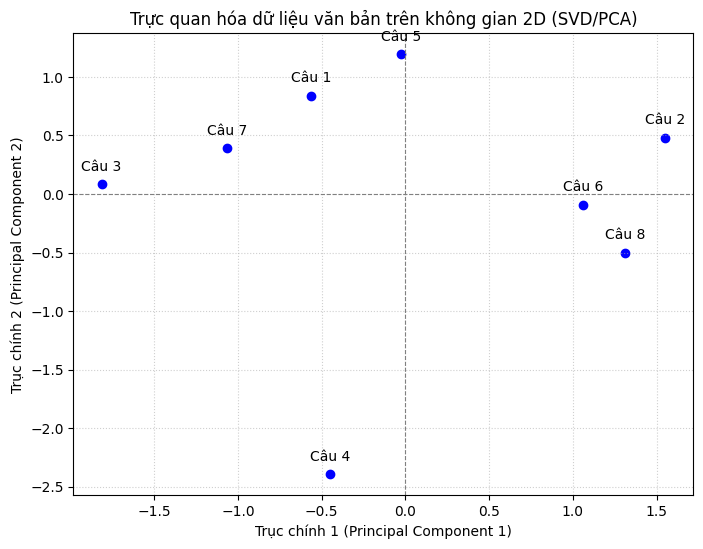

In [81]:
# Nhãn tương ứng cho từng sentence để hiển thị lên biểu đồ
labels = ['Câu 1', 'Câu 2', 'Câu 3', 'Câu 4', 'Câu 5', 'Câu 6', 'Câu 7', 'Câu 8']

plt.figure(figsize=(8, 6))

# Lấy tọa độ x (cột 0) và y (cột 1)
x = coords[:, 0]
y = coords[:, 1]

# Vẽ biểu đồ phân tán (scatter)
plt.scatter(x, y, color='blue', marker='o')

# Vòng lặp để gắn nhãn cho từng điểm dữ liệu
for i, label in enumerate(labels):
    plt.annotate(
        label,
        (x[i], y[i]),
        textcoords="offset points",
        xytext=(0, 10), # Dịch nhãn lên trên điểm 10 pixels để không bị đè
        ha='center',    # Căn giữa nhãn
        fontsize=10
    )

# Làm đẹp biểu đồ
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) # Trục hoành
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8) # Trục tung
plt.title('Trực quan hóa dữ liệu văn bản trên không gian 2D (SVD/PCA)')
plt.xlabel('Trục chính 1 (Principal Component 1)')
plt.ylabel('Trục chính 2 (Principal Component 2)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

**4. Nhận xét**

Các câu cùng chủ đề có nằm gần  nhau. Trên không gian 2D, các câu có sự tương đồng về từ vựng (cùng chủ đề) sẽ tạo thành các cụm (cluster) nằm gần nhau.
+ Ví dụ: Câu 2, 6, 8 sẽ co cụm ở một góc; Câu 1, 3, 5, 7 sẽ co cụm ở một góc khác. Các câu có chủ đề khác biệt sẽ nằm xa nhau

Liên hệ với thuật toán PCA / Eigenvectors và "Trục chính":
+ Thuật toán SVD thực hiện phương pháp PCA giúp tìm ra các "trục chính" (eigenvectors), đại diện cho các chủ đề tiềm ẩn cốt lõi mang nhiều thông tin nhất của toàn bộ tập dữ liệu.
+ Nhờ đó, khi chiếu dữ liệu xuống không gian 2D của hai trục chính này, các câu chứa bộ từ vựng giống nhau (cùng chủ đề) sẽ có tọa độ tương đồng và tự động co cụm lại gần nhau.